In [4]:
import pandas as pd
import matplotlib.pyplot as plt


In [304]:
student_observations = pd.read_csv('../data/raw/student_observations.csv')
student_observations

,student_id,assignment_id,class_num,observation_id,item_type,source_question,primary_kc_id,all_kc_ids,score,max_score,percent_score,student_response,correct_answer_or_rubric,rubric_level
0,S001,HW1,1,HW1_PCA_Q01,MCQ,PCA Q01,KC.U1.02.observational_unit_variable,KC.U1.02.observational_unit_variable,0.0,1,0.0,C,E,NaN
1,S001,HW1,1,HW1_PCA_Q02,MCQ,PCA Q02,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,1.0,1,100.0,E,E,NaN
2,S001,HW1,1,HW1_PCA_Q03,MCQ,PCA Q03,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,0.0,1,0.0,C,D,NaN
3,S001,HW1,1,HW1_PCA_Q04,MCQ,PCA Q04,KC.U1.05.categorical_freq_relative,KC.U1.05.categorical_freq_relative,1.0,1,100.0,E,E,NaN
4,S001,HW1,1,HW1_PCA_Q05,MCQ,PCA Q05,KC.U1.05.categorical_freq_relative,KC.U1.05.categorical_freq_relative,1.0,1,100.0,B,B,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21803,S025,MF2,27,MF2_FRQ6A,FRQ_Component,FRQ 6,KC.U1.09.quantitative_display_reading,KC.U1.09.quantitative_display_reading|KC.U7.11...,0.0,1,0.0,I,Rubric: identify the approximate numeric value...,I
21804,S025,MF2,27,MF2_FRQ6B,FRQ_Component,FRQ 6,KC.U7.12.mean_hypotheses,KC.U7.12.mean_hypotheses|KC.U7.11.matched_pair...,1.0,1,100.0,E,Rubric: define the population mean paired diff...,E
21805,S025,MF2,27,MF2_FRQ6C,FRQ_Component,FRQ 6,KC.U7.13.t_test_conditions,KC.U7.13.t_test_conditions|KC.U7.11.matched_pa...,0.5,1,50.0,P,"Rubric: address paired structure, random sampl...",P
21806,S025,MF2,27,MF2_FRQ6D,FRQ_Component,FRQ 6,KC.U7.14.t_test_statistic_mean,KC.U7.14.t_test_statistic_mean|KC.U7.15.p_valu...,1.0,1,100.0,E,"Rubric: use mean difference, standard error, d...",E


In [263]:
# Get all unique students and assignments
all_students = student_observations['student_id'].unique()
all_assignments = student_observations['assignment_id'].unique()
all_observations = student_observations['observation_id'].unique()
all_observations

<StringArray>
['HW1_PCA_Q01', 'HW1_PCA_Q02', 'HW1_PCA_Q03', 'HW1_PCA_Q04', 'HW1_PCA_Q05',
 'HW1_PCA_Q06', 'HW1_PCA_Q07', 'HW1_PCA_Q08', 'HW1_PCA_Q09', 'HW1_PCA_Q10',
 ...
   'MF2_FRQ4B',   'MF2_FRQ4C',   'MF2_FRQ5A',   'MF2_FRQ5B',   'MF2_FRQ5C',
   'MF2_FRQ6A',   'MF2_FRQ6B',   'MF2_FRQ6C',   'MF2_FRQ6D',   'MF2_FRQ6E']
Length: 895, dtype: str

In [6]:
student_observations['kc_id']=student_observations['primary_kc_id'].str.extract(r'(\.(\d+)\.)')[1]

In [31]:
student_observations.describe()

,class_num,score,max_score,percent_score
count,21808.000000,21808.000000,21808.0,21808.000000
mean,14.741792,0.528705,1.0,52.870506
std,8.563448,0.482724,0.0,48.272447
min,1.000000,0.000000,1.0,0.000000
25%,7.000000,0.000000,1.0,0.000000
50%,15.000000,0.500000,1.0,50.000000
75%,22.000000,1.000000,1.0,100.000000
max,27.000000,1.000000,1.0,100.000000


In [496]:
q_to_kc = student_observations.set_index('student_id').loc['S001',['assignment_id','observation_id','all_kc_ids']]
q_to_kc['kc_covered'] = q_to_kc['all_kc_ids'].str.split('|')
q_to_kc['nb_kc_covered'] = q_to_kc['all_kc_ids'].str.split('|').str.len()
q_to_kc = q_to_kc.explode('kc_covered').reset_index(drop=True)
q_to_kc[q_to_kc['observation_id']=='MF2_FRQ6D']

,assignment_id,observation_id,all_kc_ids,kc_covered,nb_kc_covered
1696,MF2,MF2_FRQ6D,KC.U7.14.t_test_statistic_mean|KC.U7.15.p_valu...,KC.U7.14.t_test_statistic_mean,2
1697,MF2,MF2_FRQ6D,KC.U7.14.t_test_statistic_mean|KC.U7.15.p_valu...,KC.U7.15.p_value_interpretation_mean,2


In [497]:
# Number of kc per question
q_to_kc.sort_values('nb_kc_covered')

,assignment_id,observation_id,all_kc_ids,kc_covered,nb_kc_covered
0,HW1,HW1_PCA_Q01,KC.U1.02.observational_unit_variable,KC.U1.02.observational_unit_variable,1
376,HW7,HW7_U4PA_Q08,KC.U4.01.probability_long_run_interpretation,KC.U4.01.probability_long_run_interpretation,1
375,HW7,HW7_U4PA_Q07,KC.U4.01.probability_long_run_interpretation,KC.U4.01.probability_long_run_interpretation,1
370,HW7,HW7_U4PA_Q04,KC.U4.03.sample_space_outcomes,KC.U4.03.sample_space_outcomes,1
1368,HW26,HW26_BOOT_MC03,KC.U10.02.bootstrap_resampling_with_replacement,KC.U10.02.bootstrap_resampling_with_replacement,1
...,...,...,...,...,...
1243,ME4,ME4_SA3_S1,KC.U7.11.matched_pairs_t_test_procedure_select...,KC.U7.12.mean_hypotheses,3
1222,ME4,ME4_SA1_S1,KC.U6.12.one_prop_hypotheses|KC.U6.01.populati...,KC.U6.11.one_prop_test_procedure_selection,4
1223,ME4,ME4_SA1_S1,KC.U6.12.one_prop_hypotheses|KC.U6.01.populati...,KC.U6.33.parameter_statistic_inference_language,4
1221,ME4,ME4_SA1_S1,KC.U6.12.one_prop_hypotheses|KC.U6.01.populati...,KC.U6.01.population_proportion_parameter,4


In [546]:
student_summary = pd.DataFrame({'observation': ['nb_students', 'nb_assignments', 'nb_observations', 'nb_items'] ,
            'value' : [student_observations['student_id'].nunique(), len(student_observations['assignment_id'].unique()), len(student_observations['observation_id'].unique()),student_observations.shape[0]]
}).set_index('observation')

nb_students = student_summary.loc['nb_students','value']
nb_assignments = student_summary.loc['nb_assignments','value']
nb_observations = student_summary.loc['nb_observations','value']
nb_items = student_summary.loc['nb_items','value']
nb_items


np.int64(21808)

In [481]:
nb_students = len(student_observations['student_id'].unique())

completed_hwk = (student_observations
                    .groupby(['student_id','assignment_id'])
                    .agg(completed=('assignment_id','count'))
                    .reset_index()
                    .groupby(['assignment_id'])
                    .agg(nb_assignments=('student_id','count')))
completed_hwk['nb_missing']=nb_students-completed_hwk['nb_assignments']
completed_hwk = completed_hwk.groupby('nb_missing').agg('count').reset_index()
completed_hwk = completed_hwk.rename(columns={'nb_missing': 'Number of missing students', 'nb_assignments': 'Number of assignments'})
completed_hwk

,Number of missing students,Number of assignments
0,0,14
1,1,11
2,2,8


In [568]:
str(round(completed_hwk[completed_hwk['Number of missing students']!=0]['Number of assignments'].sum()*100/nb_assignments,0))
str(round(completed_hwk[completed_hwk['Number of missing students']==0]['Number of assignments'].sum()*100/nb_assignments,0))
str(round(completed_hwk[completed_hwk['Number of missing students']!=0]['Number of assignments'].sum()*100/nb_assignments,0))
str(completed_hwk['Number of missing students'].max())

'2'

In [555]:
nb_assignments = student_observations['assignment_id'].nunique()

student_hwk = (student_observations
                .groupby(['student_id','assignment_id'])
                .agg(completed=('assignment_id','count'))
                .reset_index()
                .groupby(['student_id'])
                .agg(nb_students=('assignment_id','count')))
student_hwk['nb_missing']=nb_assignments-student_hwk['nb_students']
student_hwk = student_hwk.groupby('nb_missing').agg('count').reset_index()
student_hwk = student_hwk.rename(columns={'nb_missing': 'Number of missing assignments', 'nb_students': 'Number of students'})
student_hwk

,Number of missing assignments,Number of students
0,0,8
1,1,12
2,2,3
3,4,1
4,5,1


In [571]:
str(round(100*student_hwk[student_hwk['Number of missing assignments']==1]['Number of students'].sum()/student_hwk[student_hwk['Number of missing assignments']>0]['Number of students'].sum(),0))

'71.0'

In [553]:
4/33

0.12121212121212122

In [101]:
# Completed assignements per student
student_completed_hwk = student_observations.groupby(['student_id','assignment_id']).agg(completed=('assignment_id','count')).reset_index().groupby(['student_id']).agg(completed=('assignment_id','count'))

In [238]:
student_completed_hwk[student_completed_hwk['completed']!=33]

,completed
student_id,
S002,32
S003,32
S004,32
S005,32
S006,29
S007,32
S010,32
S011,32
S012,28


In [107]:
student_completed_hwk[student_completed_hwk['completed']==33].count()

completed    8
dtype: int64

In [462]:
nb_students = 25
# Completed assignements per assignement
completed_hwk = student_observations.groupby(['student_id','assignment_id']).agg(completed=('assignment_id','count')).reset_index().groupby(['assignment_id']).agg(nb_assignments=('student_id','count'))
completed_hwk['nb_missing']=nb_students-completed_hwk['nb_assignments']

In [463]:
completed_hwk = completed_hwk.groupby('nb_missing').agg('count')

In [464]:
completed_hwk

,nb_assignments
nb_missing,
0,14
1,11
2,8


In [111]:
completed_hwk[completed_hwk['completed']!=25].count()

completed    19
dtype: int64

In [33]:
student_roster = pd.read_csv('../data/raw/student_roster.csv')

In [38]:
# Number of students
student_roster.shape[0]

25

In [39]:
class_plan = pd.read_csv('../data/raw/class_plan.csv')

In [42]:
# Number of assessment opportunities
class_plan['homework_id'].nunique()

33

In [44]:
# Total number of observations
class_plan['homework_observations'].sum()

np.int64(895)

In [303]:
student_observations

,student_id,assignment_id,class_num,observation_id,item_type,source_question,primary_kc_id,all_kc_ids,score,max_score,percent_score,student_response,correct_answer_or_rubric,rubric_level,kc_id,nb_kc_covered
0,S001,HW1,1,HW1_PCA_Q01,MCQ,PCA Q01,KC.U1.02.observational_unit_variable,KC.U1.02.observational_unit_variable,0.0,1,0.0,C,E,NaN,02,[KC.U1.02.observational_unit_variable]
1,S001,HW1,1,HW1_PCA_Q02,MCQ,PCA Q02,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,1.0,1,100.0,E,E,NaN,03,[KC.U1.03.variable_type_cat_quant]
2,S001,HW1,1,HW1_PCA_Q03,MCQ,PCA Q03,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,0.0,1,0.0,C,D,NaN,03,[KC.U1.03.variable_type_cat_quant]
3,S001,HW1,1,HW1_PCA_Q04,MCQ,PCA Q04,KC.U1.05.categorical_freq_relative,KC.U1.05.categorical_freq_relative,1.0,1,100.0,E,E,NaN,05,[KC.U1.05.categorical_freq_relative]
4,S001,HW1,1,HW1_PCA_Q05,MCQ,PCA Q05,KC.U1.05.categorical_freq_relative,KC.U1.05.categorical_freq_relative,1.0,1,100.0,B,B,NaN,05,[KC.U1.05.categorical_freq_relative]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21803,S025,MF2,27,MF2_FRQ6A,FRQ_Component,FRQ 6,KC.U1.09.quantitative_display_reading,KC.U1.09.quantitative_display_reading|KC.U7.11...,0.0,1,0.0,I,Rubric: identify the approximate numeric value...,I,09,"[KC.U1.09.quantitative_display_reading, KC.U7...."
21804,S025,MF2,27,MF2_FRQ6B,FRQ_Component,FRQ 6,KC.U7.12.mean_hypotheses,KC.U7.12.mean_hypotheses|KC.U7.11.matched_pair...,1.0,1,100.0,E,Rubric: define the population mean paired diff...,E,12,"[KC.U7.12.mean_hypotheses, KC.U7.11.matched_pa..."
21805,S025,MF2,27,MF2_FRQ6C,FRQ_Component,FRQ 6,KC.U7.13.t_test_conditions,KC.U7.13.t_test_conditions|KC.U7.11.matched_pa...,0.5,1,50.0,P,"Rubric: address paired structure, random sampl...",P,13,"[KC.U7.13.t_test_conditions, KC.U7.11.matched_..."
21806,S025,MF2,27,MF2_FRQ6D,FRQ_Component,FRQ 6,KC.U7.14.t_test_statistic_mean,KC.U7.14.t_test_statistic_mean|KC.U7.15.p_valu...,1.0,1,100.0,E,"Rubric: use mean difference, standard error, d...",E,14,"[KC.U7.14.t_test_statistic_mean, KC.U7.15.p_va..."


In [306]:
student_kc_coverage = student_observations[(student_observations['student_id'] == 'S012') | (student_observations['student_id'] == 'S001')].groupby(['student_id','primary_kc_id'])[['assignment_id']].agg('count').reset_index()

In [8]:
import altair as alt

In [309]:
kc_coverage = pd.read_csv('../data/raw/kc_coverage.csv')

In [504]:
kc_coverage['num_items'].max()*nb_students

np.int64(725)

In [505]:
kc_coverage['num_items'].min()*nb_students

np.int64(0)

In [519]:
def get_student_kc_coverage(student_id, student_observations, kc_coverage):
    q_to_kc = (student_observations
               .set_index('student_id')
               .loc[student_id, ['assignment_id', 'observation_id', 'all_kc_ids']])
    q_to_kc['kc_id'] = q_to_kc['all_kc_ids'].str.split('|')
    q_to_kc = (q_to_kc
               .explode('kc_id')
               .reset_index()
               .groupby('kc_id')
               .agg(num_items=('assignment_id', 'count'))
               .reset_index())
    
    missing_kcs = set(kc_coverage) - set(q_to_kc['kc_id'])
    q_to_kc = pd.concat([q_to_kc, pd.DataFrame({'kc_id': list(missing_kcs), 'num_items': 0})])
    q_to_kc['student_id'] = student_id
    return q_to_kc

In [522]:
kc_coverage

,kc_id,kc_label,intro_class,reporting_group,num_items,num_primary_items,assignments,observation_ids
0,KC.U1.01.statistical_context,Statistical context and investigative question,1,Data foundations,1,0,HW1,HW1_SGFRQ1_Q1a
1,KC.U1.02.observational_unit_variable,Observational unit and variable,1,Data foundations,2,2,HW1|ME1,HW1_PCA_Q01|ME1_MCQ01
2,KC.U1.03.variable_type_cat_quant,Categorical vs quantitative variable,1,Data foundations,8,3,HW1|HW2|HW3|ME1|MF2,HW1_PCA_Q02|HW1_PCA_Q03|HW2_PCA_Q13|HW2_PCA_Q1...
3,KC.U1.04.variable_type_discrete_continuous,Discrete vs continuous quantitative variable,1,Data foundations,5,4,HW2|ME1|MF2,HW2_PCA_Q13|HW2_PCA_Q14|HW2_PCA_Q15|ME1_MCQ03|...
4,KC.U1.05.categorical_freq_relative,Frequency and relative-frequency tables,1,Categorical data,14,7,HW1|ME1|MF1|MF2,HW1_PCA_Q04|HW1_PCA_Q05|HW1_PCA_Q06|HW1_PCA_Q0...
...,...,...,...,...,...,...,...,...
251,KC.U10.14.power_beta_relationship_extension,Power and beta relationship,27,Unit 10: Bootstrapping and Power,2,2,HW27|MF2,HW27_PWR_MC03|MF2_MCQ36
252,KC.U10.15.rejection_region_power_calculation,Power calculation using rejection region,27,Unit 10: Bootstrapping and Power,3,3,HW27,HW27_PWR_MC09|HW27_PWR_FRQ18|HW27_PWR_FRQ19
253,KC.U10.16.factors_affecting_power,Factors affecting power,27,Unit 10: Bootstrapping and Power,7,5,HW27,HW27_PWR_MC04|HW27_PWR_MC06|HW27_PWR_MC07|HW27...
254,KC.U10.17.power_specific_alternative,Power for a specific alternative value,27,Unit 10: Bootstrapping and Power,4,2,HW27,HW27_PWR_MC08|HW27_PWR_MC14|HW27_PWR_FRQ19|HW2...


In [521]:
get_student_kc_coverage('S001', student_observations, kc_coverage['kc_id'])
q_to_kc
kc_summary = pd.DataFrame({
        'observation': ['nb_kc', 
                        'nb_skills', 
                        'nb_sub_skills',
                        'max_obs_per_kc',
                        'min_obs_per_kc'] ,
        'value' : [kc_coverage['kc_id'].nunique(), 
                    4, 
                    18,
                    kc_coverage['num_items'].max()*student_observations['student_id'].nunique(),
                    kc_coverage['num_items'].min()*student_observations['student_id'].nunique()
                    ]})
q_to_kc

,kc_id,num_items,student_id
0,KC.U1.01.statistical_context,1,S001
1,KC.U1.02.observational_unit_variable,2,S001
2,KC.U1.03.variable_type_cat_quant,8,S001
3,KC.U1.04.variable_type_discrete_continuous,5,S001
4,KC.U1.05.categorical_freq_relative,14,S001
...,...,...,...
251,KC.U9.20.regression_inference_scope_and_predic...,5,S001
0,KC.U3.12.observational_study,0,S001
1,KC.U9.09.regression_independence_random_condition,0,S001
2,KC.U4.14.random_variable_definition,0,S001


In [507]:
pd.DataFrame({
            'observation': ['nb_kc', 
                            'nb_skills', 
                            'nb_sub_skills',
                            'nb_kc_per_q',
                            'max_obs_per_kc',
                            'min_obs_per_kc'] ,
            'value' : [kc_coverage['kc_id'].nunique(), 
                       4, 
                       18,
                       q_to_kc['nb_kc_covered'].max(),
                       kc_coverage['num_items'].max()*student_observations['student_id'].nunique(),
                       kc_coverage['num_items'].min()*student_observations['student_id'].nunique()
                       ]
                       })

,observation,value
0,nb_kc,256
1,nb_skills,4
2,nb_sub_skills,18
3,nb_kc_per_q,4
4,max_obs_per_kc,725
5,min_obs_per_kc,0


In [501]:
q_to_kc['nb_kc_covered'].max()

np.int64(4)

In [484]:
kc_nodes = pd.read_csv('../data/raw/kc_nodes.csv')

In [492]:
kc_nodes['ap_skill_refs'].str.split(['|',';'])

TypeError: unhashable type: 'list'

In [310]:
kc_coverage.sort_values('num_items')

,kc_id,kc_label,intro_class,reporting_group,num_items,num_primary_items,assignments,observation_ids
226,KC.U9.09.regression_independence_random_condition,Regression inference condition: random and ind...,23,Unit 9: Inference for Slopes,0,0,NaN,NaN
87,KC.U4.14.random_variable_definition,Random variable definition,9,Unit 4: Random variables,0,0,NaN,NaN
59,KC.U3.12.observational_study,Observational study identification,5,Unit 3: Study type,0,0,NaN,NaN
119,KC.U5.12.sample_proportion_probability,Probability involving a sample proportion,12,Unit 5: Sample proportions,0,0,NaN,NaN
174,KC.U7.08.matched_pairs_interval_procedure,Matched-pairs t-interval,18,Unit 7: Matched pairs,1,1,HW18,HW18_U7A_Q02
...,...,...,...,...,...,...,...,...
58,KC.U3.11.generalization_scope,Scope of generalization,5,Unit 3: Data collection,20,14,HW18|HW26|HW5|HW6|ME2|ME3|MF1|MF2,HW5_U3PCA_Q04|HW5_U3PCA_Q05|HW5_U3PCA_Q06|HW5_...
18,KC.U1.19.z_score_compute_interpret,Compute and interpret z-scores,3,Standardization,25,5,HW11|HW3|ME1|ME3|MF1|MF2,HW3_PCB_Q15|HW3_PCB_Q16|HW3_PCB_Q17|HW3_PCB_Q1...
148,KC.U6.15.p_value_calculate_interpret,P-value calculation and interpretation,15,Unit 6: Hypothesis tests,25,7,HW15|HW17|HW26|ME3|ME4|MF1|MF2,HW15_U6B_Q08|HW15_U6B_Q10|HW15_U6B_Q11|HW15_U6...
89,KC.U4.16.expected_value_calculation,Expected value calculation,9,Unit 4: Random variables,27,17,HW10|HW9|ME2|ME3|MF2,HW9_U4PB_Q07|HW9_U4PB_Q08|HW9_U4PB_Q11|HW9_U4P...


In [387]:
chart = alt.Chart(kc_coverage).mark_bar().encode(
    x=alt.X('num_items', title='Number of items').bin(maxbins=15),
    y=alt.Y('count()', title='Number of KCs'),
    tooltip=['count()']  
).properties(
    title='KC Coverage Imbalance'
)
chart

alt.Chart(...)

In [ ]:
# List of questions student completed

q_to_kc = student_observations.set_index('student_id').loc['S001',['assignment_id','observation_id','all_kc_ids']]
q_to_kc['kc_covered'] = q_to_kc['all_kc_ids'].str.split('|')
q_to_kc = q_to_kc.explode('kc_covered').reset_index().groupby('kc_covered').agg(num_items=('assignment_id','count')).reset_index()

result = list(set(q_to_kc['kc_covered']) ^ set(kc_coverage['kc_id']))

s1_kc_coverage = pd.concat((q_to_kc,pd.DataFrame({'kc_covered' : result, 'num_items' : [0]*len(result)}) ))
s1_kc_coverage['student_id'] = ['S001'] * 256

q_to_kc = student_observations.set_index('student_id').loc['S012',['assignment_id','observation_id','all_kc_ids']]
q_to_kc['kc_covered'] = q_to_kc['all_kc_ids'].str.split('|')
q_to_kc = q_to_kc.explode('kc_covered').reset_index().groupby('kc_covered').agg(num_items=('assignment_id','count')).reset_index()

result = list(set(q_to_kc['kc_covered']) ^ set(kc_coverage['kc_id']))

s12_kc_coverage = pd.concat((q_to_kc,pd.DataFrame({'kc_covered' : result, 'num_items' : [0]*len(result)}) ))
s12_kc_coverage['student_id'] = ['S012'] * 256


comparison = pd.concat((s12_kc_coverage,s1_kc_coverage))

In [419]:
def get_student_kc_coverage(student_id, student_observations, kc_coverage):
    q_to_kc = (student_observations
               .set_index('student_id')
               .loc[student_id, ['assignment_id', 'observation_id', 'all_kc_ids']])
    q_to_kc['kc_covered'] = q_to_kc['all_kc_ids'].str.split('|')
    q_to_kc = (q_to_kc.explode('kc_covered')
               .reset_index()
               .groupby('kc_covered')
               .agg(num_items=('assignment_id', 'count'))
               .reset_index())
    
    missing_kcs = set(kc_coverage) - set(q_to_kc['kc_covered'])
    q_to_kc = pd.concat([q_to_kc, pd.DataFrame({'kc_covered': list(missing_kcs), 'num_items': 0})])
    q_to_kc['student_id'] = student_id
    return q_to_kc

def create_comparison_kc_coverage_chart(kc : pd.DataFrame, student_observations : pd.DataFrame):
    comparison = pd.concat([
        get_student_kc_coverage('S001', student_observations, kc['kc_id']),
        get_student_kc_coverage('S012', student_observations, kc['kc_id'])
    ])

    chart = alt.Chart(comparison).mark_bar().encode(
        x=alt.X('num_items', title='Number of items').bin(maxbins=15),
        y=alt.Y('count()', title='Number of KCs'),
        tooltip=['count()'] 
    ).facet(
        column = alt.Column('student_id', title = 'Student')
    ).properties(
        title='KC Coverage Imbalance'
    )
    
    return chart

create_comparison_kc_coverage_chart(kc_coverage, student_observations)

alt.FacetChart(...)

In [416]:
chart = alt.Chart(comparison).mark_bar().encode(
    x=alt.X('num_items', title='Number of items').bin(maxbins=15),
    y=alt.Y('count()', title='Number of KCs'),
    tooltip=['count()'] 
).facet(
    column = alt.Column('student_id', title = 'Student')
).properties(
    title='KC Coverage Imbalance'
)
chart

alt.FacetChart(...)

In [10]:
assignement_avg = student_observations.groupby(['student_id','assignment_id']).agg('sum').reset_index()[['student_id','assignment_id','score','max_score']]
assignement_avg['percent_score'] = round(assignement_avg['score']/assignement_avg['max_score']*100,1)

In [11]:
assignement_avg

,student_id,assignment_id,score,max_score,percent_score
0,S001,HW1,12.0,21,57.1
1,S001,HW10,12.0,31,38.7
2,S001,HW11,8.5,18,47.2
3,S001,HW12,7.0,18,38.9
4,S001,HW13,5.5,16,34.4
...,...,...,...,...,...
793,S025,ME2,25.5,42,60.7
794,S025,ME3,32.5,60,54.2
795,S025,ME4,23.0,55,41.8
796,S025,MF1,14.0,60,23.3


In [12]:
chart = alt.Chart(assignement_avg).mark_bar().encode(
    x=alt.X('percent_score', title='Score (%)', bin=True),
    y=alt.Y('count()', title='Nb of students') 
)

mean_line = alt.Chart(assignement_avg).mark_rule(color='red').encode(
    x='mean(percent_score):Q'
)

(chart + mean_line).facet(
    column=alt.Column('assignment_id:N', title = 'Assignment'), 
    title='Wide spread in student performance within assignments'
)

alt.FacetChart(...)

In [13]:
chart = alt.Chart(assignement_avg).mark_boxplot().encode(
    x=alt.X('percent_score'),
    y= alt.Y('assignment_id', sort='-x')
).properties(
    title='Student performance across assignements'
)
chart

alt.Chart(...)

In [14]:
chart = alt.Chart(assignement_avg).mark_boxplot().encode(
    x=alt.X('student_id', sort='-y'),
    y=alt.Y('percent_score')
).properties(
    title='Student performance across assignements'
)
chart

alt.Chart(...)

In [15]:
student_avg = student_observations.groupby(['student_id']).agg('sum').reset_index()[['student_id','score','max_score']]
student_avg['percent_score'] = round(student_avg['score']/student_avg['max_score']*100,1)

In [16]:
student_avg

,student_id,score,max_score,percent_score
0,S001,342.0,895,38.2
1,S002,658.0,880,74.8
2,S003,587.0,876,67.0
3,S004,677.5,881,76.9
4,S005,559.0,883,63.3
5,S006,304.5,774,39.3
6,S007,398.0,879,45.3
7,S008,512.5,895,57.3
8,S009,511.0,895,57.1
9,S010,357.5,877,40.8


In [17]:
chart = alt.Chart(student_avg).mark_bar().encode(
    x=alt.X('percent_score', title='Score (%)', bin=True),
    y=alt.Y('count()', title='Nb of students') 
).properties(
    title='Wide spread in student performance'
)
chart

alt.Chart(...)

In [18]:
overall_scores = pd.read_csv('../data/raw/overall_scores.csv')

In [20]:
chart = alt.Chart(overall_scores).mark_bar().encode(
    x=alt.X('count()', title='Nb of students'),
    y=alt.Y('performance_band', title='Performance band', sort='-x') 
).properties(
    title='Most of the students are performing as expected'
)
chart

alt.Chart(...)

In [28]:
import networkx as nx

In [112]:
kc_edges = pd.read_csv('../data/raw/kc_edges.csv')
kc_nodes = pd.read_csv('../data/raw/kc_nodes.csv')

In [114]:
# Number of KC
kc_nodes.shape[0]

256

In [118]:
kc_nodes['ap_skill_refs']

0          1.A;2.A
1              2.A
2              2.A
3              2.A
4          3.A;4.A
          ...     
251        3.C|4.F
252    3.C|3.E|4.F
253    2.D|4.F|4.G
254        2.C|4.F
255    2.D|4.F|4.G
Name: ap_skill_refs, Length: 256, dtype: str

In [22]:
kc_edges['source']=kc_edges['source_kc_id'].str.extract(r'(\.(\d+)\.)')[1]
kc_edges['target']=kc_edges['target_kc_id'].str.extract(r'(\.(\d+)\.)')[1]

In [23]:
kc_edges.head()

,edge_id,source_kc_id,target_kc_id,relation,official,confidence,evidence_note,source,target
0,E001,KC.U1.01.statistical_context,KC.U1.02.observational_unit_variable,supports,False,0.80,Context helps identify what is measured.,01,02
1,E002,KC.U1.02.observational_unit_variable,KC.U1.03.variable_type_cat_quant,prerequisite,False,0.90,You classify the variable after identifying th...,02,03
2,E003,KC.U1.03.variable_type_cat_quant,KC.U1.04.variable_type_discrete_continuous,prerequisite,False,0.85,Discrete/continuous only applies to quantitati...,03,04
3,E004,KC.U1.03.variable_type_cat_quant,KC.U1.05.categorical_freq_relative,supports,False,0.75,Categorical variables are summarized in tables.,03,05
4,E005,KC.U1.05.categorical_freq_relative,KC.U1.06.categorical_bar_pie_segmented,supports,False,0.80,Tables support interpreting categorical graphs.,05,06


In [24]:
edge_list = []
for index in kc_edges.index:
    if kc_edges.loc[index,'relation']=='prerequisite':
        edge_list.append((kc_edges.loc[index,'source'],kc_edges.loc[index,'target']))
    if kc_edges.loc[index,'relation']=='supports':
        edge_list.append((kc_edges.loc[index,'target'],kc_edges.loc[index,'source']))

edge_list

[('02', '01'),
 ('02', '03'),
 ('03', '04'),
 ('05', '03'),
 ('06', '05'),
 ('07', '05'),
 ('08', '06'),
 ('08', '07'),
 ('27', '01'),
 ('09', '04'),
 ('09', '10'),
 ('11', '10'),
 ('11', '12'),
 ('11', '13'),
 ('14', '13'),
 ('14', '15'),
 ('16', '10'),
 ('16', '12'),
 ('16', '15'),
 ('17', '11'),
 ('17', '14'),
 ('25', '12'),
 ('25', '14'),
 ('26', '09'),
 ('11', '26'),
 ('12', '19'),
 ('13', '19'),
 ('19', '18'),
 ('20', '10'),
 ('21', '20'),
 ('21', '19'),
 ('19', '22'),
 ('22', '20'),
 ('22', '21'),
 ('23', '22'),
 ('19', '24'),
 ('24', '22'),
 ('23', '25'),
 ('01', '05'),
 ('01', '02'),
 ('01', '03'),
 ('04', '02'),
 ('03', '04'),
 ('05', '03'),
 ('04', '05'),
 ('06', '09'),
 ('06', '07'),
 ('06', '08'),
 ('09', '07'),
 ('09', '10'),
 ('11', '07'),
 ('17', '11'),
 ('12', '07'),
 ('13', '08'),
 ('14', '13'),
 ('15', '13'),
 ('13', '16'),
 ('17', '16'),
 ('18', '16'),
 ('19', '09'),
 ('20', '13'),
 ('21', '11'),
 ('21', '17'),
 ('17', '12'),
 ('19', '14'),
 ('09', '18'),
 ('01', '0

In [25]:
kc_nodes = pd.read_csv('../data/raw/kc_nodes.csv')
kc_nodes['node_id']=kc_nodes['kc_id'].str.extract(r'(\.(\d+)\.)')[1]

In [26]:
labels = {}
#['1.A', '2.A', '2.B', '3.A', '3.B', '3.C','3.D','4.A','4.B','4.C','4.D','4.E','4.F']
for skill_ref in ['1.A', '2.A', '2.B', '3.A', '3.B', '3.C','3.D','4.A','4.B','4.C','4.D','4.E','4.F'] :
    nodes=list(kc_nodes[kc_nodes['ap_skill_refs'].str.contains(skill_ref)]['node_id'])
    edge_list=[]
    for node in nodes:
        for target in list(kc_edges[kc_edges['source']==node].index):
            if kc_edges.loc[target,'target'] in nodes:
                if kc_edges.loc[target,'relation']=='prerequisite':
                    edge_list.append((kc_edges.loc[target,'source'],kc_edges.loc[target,'target']))
                elif kc_edges.loc[target,'relation']=='supports':
                    edge_list.append((kc_edges.loc[target,'target'],kc_edges.loc[target,'source']))
    graph={'nodes' : nodes,
           'edges' : edge_list}
    labels[skill_ref]=graph

labels

{'1.A': {'nodes': ['01', '27'], 'edges': [('27', '01'), ('01', '01')]},
 '2.A': {'nodes': ['01',
   '02',
   '03',
   '04',
   '27',
   '01',
   '08',
   '01',
   '02',
   '15',
   '16',
   '03',
   '14',
   '06',
   '01',
   '09',
   '01',
   '03'],
  'edges': [('02', '01'),
   ('27', '01'),
   ('01', '02'),
   ('01', '03'),
   ('01', '01'),
   ('02', '01'),
   ('02', '01'),
   ('04', '01'),
   ('09', '01'),
   ('02', '01'),
   ('01', '04'),
   ('02', '01'),
   ('01', '02'),
   ('09', '01'),
   ('02', '03'),
   ('04', '02'),
   ('03', '02'),
   ('04', '02'),
   ('02', '03'),
   ('04', '02'),
   ('03', '02'),
   ('08', '02'),
   ('03', '04'),
   ('03', '04'),
   ('04', '03'),
   ('06', '03'),
   ('03', '04'),
   ('08', '03'),
   ('04', '03'),
   ('03', '06'),
   ('03', '04'),
   ('03', '03'),
   ('03', '04'),
   ('03', '15'),
   ('04', '03'),
   ('09', '04'),
   ('06', '04'),
   ('08', '04'),
   ('04', '06'),
   ('09', '04'),
   ('02', '01'),
   ('27', '01'),
   ('01', '02'),
   ('01',

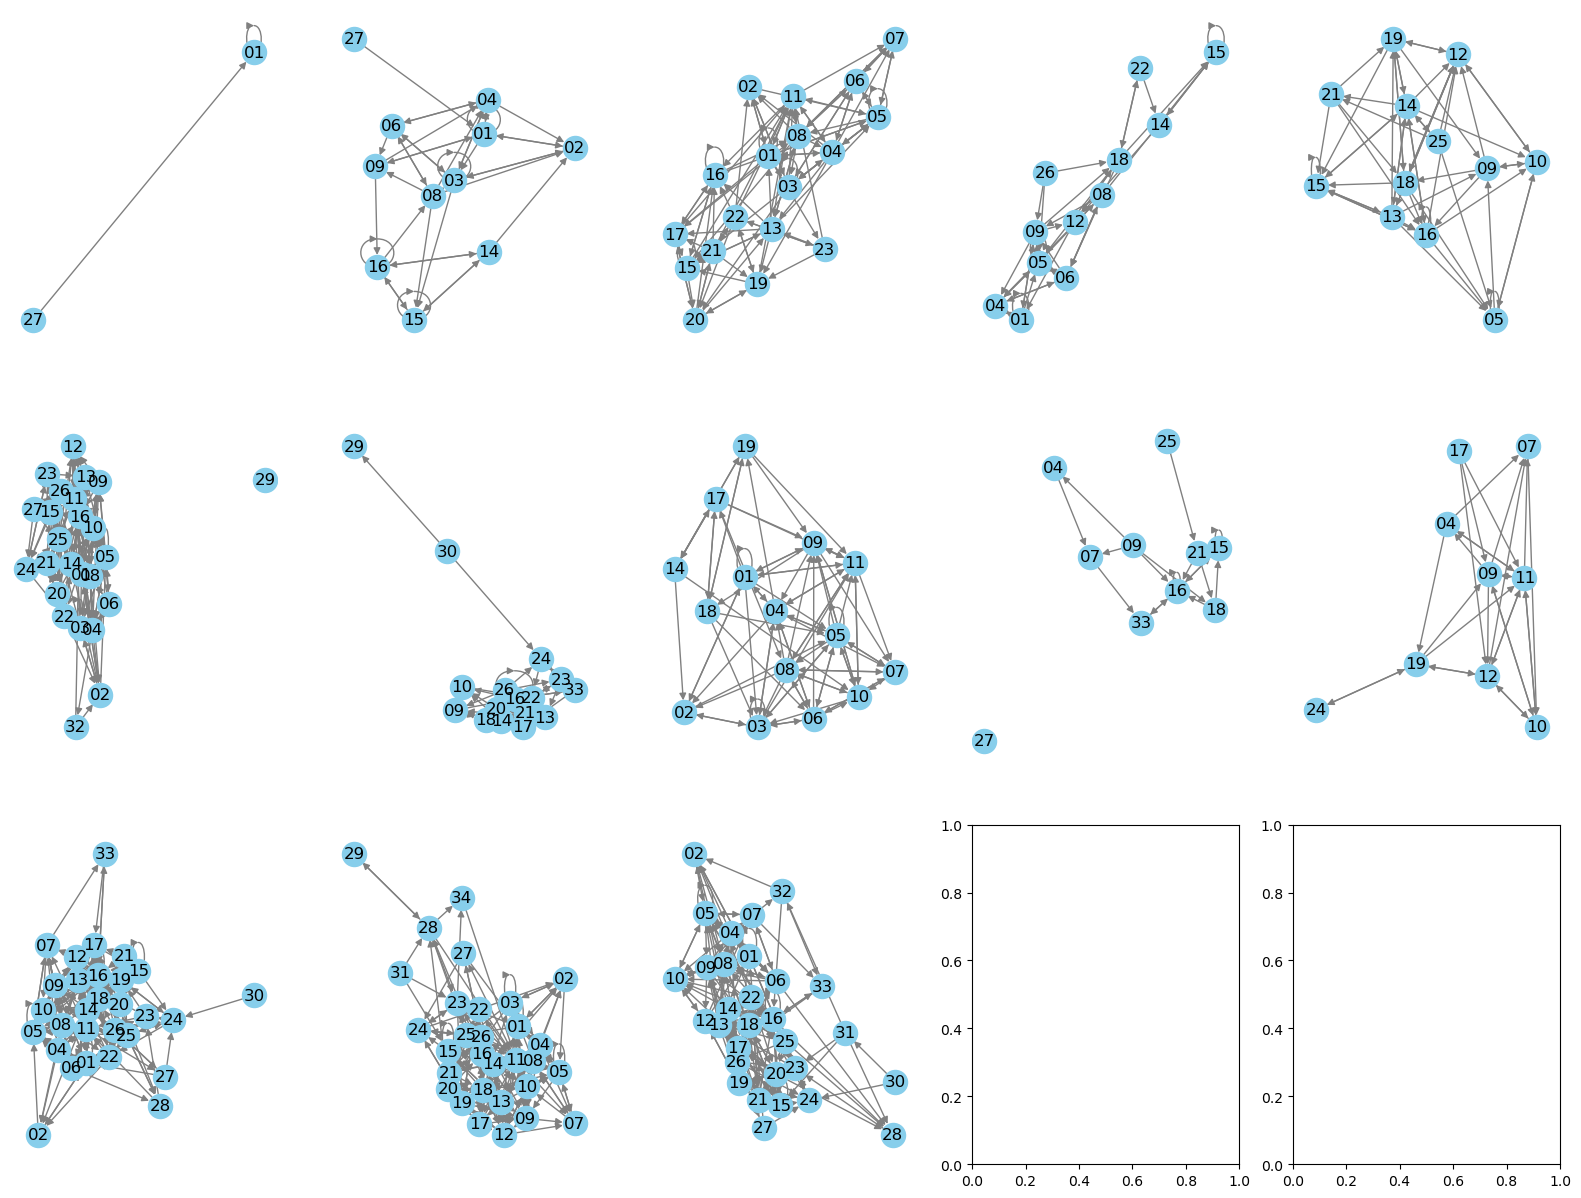

In [29]:
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 15))
axes = axes.flatten()

for i,skill_ref in enumerate(labels) : 
    G = nx.DiGraph()
    for node in labels[skill_ref]['nodes']:
        G.add_node(node)

    for edge in labels[skill_ref]['edges']:
        u,v = edge
        G.add_edge(u,v)

    nx.draw(G, ax=axes[i], with_labels=True, node_color='skyblue', edge_color='gray')

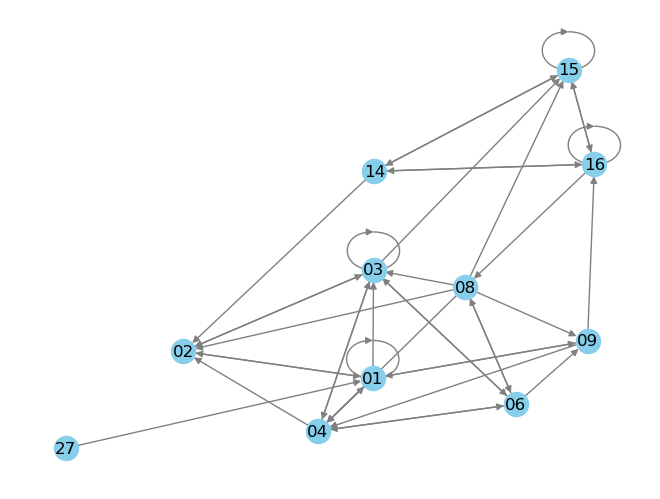

In [30]:
G = nx.DiGraph()
for node in labels['2.A']['nodes']:
    G.add_node(node)

for edge in labels['2.A']['edges']:
    u,v = edge
    G.add_edge(u,v)

nx.draw(G, with_labels=True, node_color='skyblue', edge_color='gray')